# Load both logs

In [4]:
import json
import matplotlib.pyplot as plt


scratch_path = "../evaluation/scratch_ncf_log.json"
pytorch_path = "../evaluation/pytorch_ncf_log.json"

try:
    scratch = json.load(open(scratch_path))
    pytorch = json.load(open(pytorch_path))
    print("Logs loaded successfully!")
except FileNotFoundError as e:
    print(f" Still can't find it. Current Directory: {os.getcwd()}")
    print(f"Error details: {e}")

s_epochs = [e["epoch"]    for e in scratch["epochs"]]
s_loss   = [e["loss"]     for e in scratch["epochs"]]
s_hit    = [e["hit_at_10"] for e in scratch["epochs"] if e["hit_at_10"]]

p_epochs = [e["epoch"]    for e in pytorch["epochs"]]
p_loss   = [e["loss"]     for e in pytorch["epochs"]]
p_hit    = [e["hit_at_10"] for e in pytorch["epochs"] if e["hit_at_10"]]

Logs loaded successfully!


# Loss curve

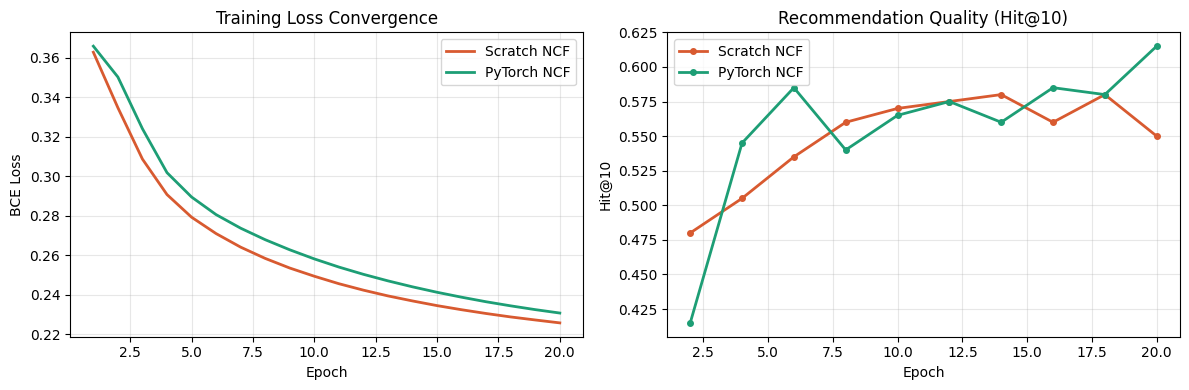

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(s_epochs, s_loss, label="Scratch NCF", color="#D85A30", lw=2)
axes[0].plot(p_epochs, p_loss, label="PyTorch NCF", color="#1D9E75", lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Training Loss Convergence"); axes[0].legend()
axes[0].grid(True, alpha=0.3)

hit_epochs = [e["epoch"] for e in scratch["epochs"] if e["hit_at_10"]]
axes[1].plot(hit_epochs, s_hit, label="Scratch NCF", color="#D85A30",
             lw=2, marker="o", ms=4)
axes[1].plot(hit_epochs, p_hit, label="PyTorch NCF", color="#1D9E75",
             lw=2, marker="o", ms=4)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Hit@10")
axes[1].set_title("Recommendation Quality (Hit@10)"); axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../evaluation/figures/thesis/figure_4_1_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# Training time bar chart

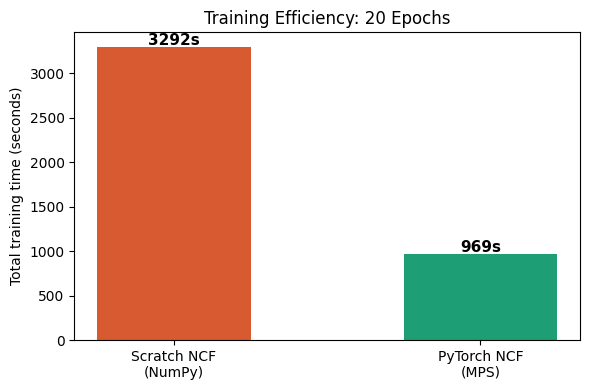

In [8]:
s_times = [e["time_sec"] for e in scratch["epochs"]]
p_times = [e["time_sec"] for e in pytorch["epochs"]]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Scratch NCF\n(NumPy)", "PyTorch NCF\n(MPS)"],
       [sum(s_times), sum(p_times)],
       color=["#D85A30", "#1D9E75"], width=0.5)
ax.set_ylabel("Total training time (seconds)")
ax.set_title("Training Efficiency: 20 Epochs")
for i, v in enumerate([sum(s_times), sum(p_times)]):
    ax.text(i, v + 20, f"{v:.0f}s", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../evaluation/figures/thesis/figure_4_2_training_time.png", dpi=150, bbox_inches="tight")
plt.show()